# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


#### Project Link
https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction?resource=download&select=train.csv

#### Challenge
This project focuses on identifying which controllable airline service factors have the strongest effect on passenger dissatisfaction. The main goal is to understand which improvements airlines should prioritize first in order to improve the passenger experience. I am especially interested in factors such as seat comfort, online boarding, inflight wifi service, cleanliness, food and drink, leg room service, and delay-related measures.

#### Data Description
The dataset is an airline passenger satisfaction survey. It includes passenger information such as gender, age, customer type, type of travel, class, and flight distance, along with service-related variables such as inflight wifi service, ease of online booking, gate location, food and drink, online boarding, seat comfort, inflight entertainment, on-board service, leg room service, baggage handling, check-in service, inflight service, cleanliness, departure delay in minutes, and arrival delay in minutes. The target variable is Satisfaction. The dataset was cleaned for classification and is provided in tabular form through training and testing files.

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv(r"C:\Users\Renuka\Downloads\train.csv\train.csv")

In [2]:
# Creating a Basic Summary Table
# Note: Our target variable is "Satisfaction" for future reference.
summary_rows = []

for column in data.columns:
    
    # Decide if the column is categorical or numerical
    if data[column].dtype == "object":
        column_type = "Categorical"
        values_or_range = ", ".join(data[column].unique())
    else:
        column_type = "Numerical"
        values_or_range = str(data[column].min()) + " to " + str(data[column].max())
    
    # Count missing values
    missing_count = data[column].isnull().sum()
    
    # Count unique values
    unique_count = data[column].nunique()
    
    # Add the information to the summary list
    summary_rows.append({
        "Column Name": column,
        "Type": column_type,
        "Values or Range": values_or_range,
        "Missing Values": missing_count,
        "Number of Unique Values": unique_count
    })

# Convert the list into a DataFrame/table
summary_table = pd.DataFrame(summary_rows)

summary_table

,Column Name,Type,Values or Range,Missing Values,Number of Unique Values
0,Unnamed: 0,Numerical,0 to 103903,0,103904
1,id,Numerical,1 to 129880,0,103904
2,Gender,Categorical,"Male, Female",0,2
3,Customer Type,Categorical,"Loyal Customer, disloyal Customer",0,2
4,Age,Numerical,7 to 85,0,75
5,Type of Travel,Categorical,"Personal Travel, Business travel",0,2
6,Class,Categorical,"Eco Plus, Business, Eco",0,3
7,Flight Distance,Numerical,31 to 4983,0,3802
8,Inflight wifi service,Numerical,0 to 5,0,6
9,Departure/Arrival time convenient,Numerical,0 to 5,0,6


### Table Summary

Most of the dataset has no missing values. The only column with missing data is **Arrival Delay in Minutes**, which has **310 missing values**. This column is numerical, so the missing values can later be handled by using the median, mean, or by removing those rows.

The dataset includes categorical features such as **Gender**, **Customer Type**, **Type of Travel**, **Class**, and **satisfaction**. These columns contain text categories instead of numbers.

The dataset also includes numerical features such as **Age**, **Flight Distance**, service rating columns, and delay columns. Many of the service rating columns use a scale from **0 to 5**, where higher values usually represent better service ratings.

The target column is **satisfaction**, which has two categories: **neutral or dissatisfied** and **satisfied**. This confirms that the project is a classification problem.

In [3]:
# Removing The Redundant Column, I remove The {Unnamed: 0} column because it is just an index 
# and does not provide any useful information for our analysis.
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
print(data.head())
print(data.columns)

       id  Gender      Customer Type  Age   Type of Travel     Class  \
0   70172    Male     Loyal Customer   13  Personal Travel  Eco Plus   
1    5047    Male  disloyal Customer   25  Business travel  Business   
2  110028  Female     Loyal Customer   26  Business travel  Business   
3   24026  Female     Loyal Customer   25  Business travel  Business   
4  119299    Male     Loyal Customer   61  Business travel  Business   

   Flight Distance  Inflight wifi service  Departure/Arrival time convenient  \
0              460                      3                                  4   
1              235                      3                                  2   
2             1142                      2                                  2   
3              562                      2                                  5   
4              214                      3                                  3   

   Ease of Online booking  ...  Inflight entertainment  On-board service  \
0         

In [4]:
#Now Lets Check for Duplicate rows as well :) 
duplicate_rows = data.duplicated().sum() 
print(f"Number of duplicate rows: {duplicate_rows}")
# Seems like there are no duplicate rows in the dataset, which is good for our analysis.

Number of duplicate rows: 0


## Handling the missing values

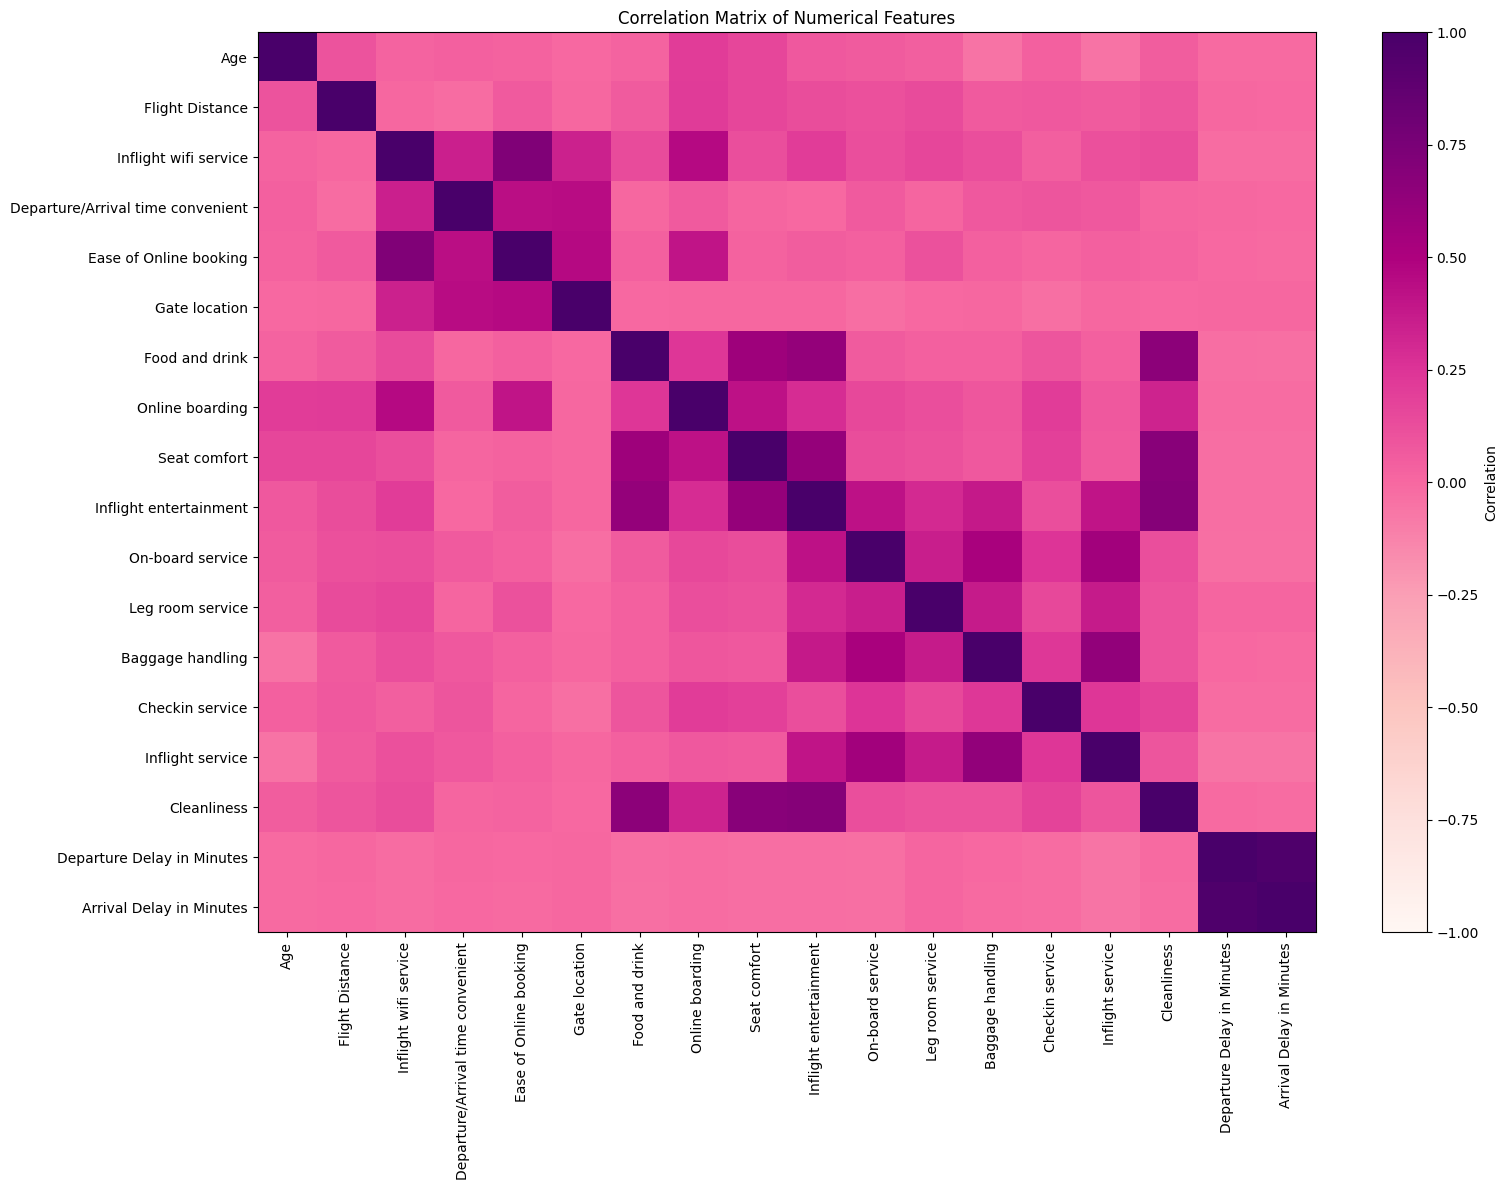

In [5]:
# Okay, I know that visualizing come a little later according the templeate but I need the corolation, 
# so I can fill in the missing values. :)
# So this is the code to check, the relationship between numerical features using a correlation map
import matplotlib.pyplot as plt

# Select only numerical columns
numerical_data = data.select_dtypes(include=["int64", "float64"])

# Remove id from the correlation map because it is just an identification number
numerical_data = numerical_data.drop(columns=["id"], errors="ignore")

# Create the correlation matrix
correlation_matrix = numerical_data.corr()

# Make the correlation heatmap
plt.figure(figsize=(16, 12))

plt.imshow(correlation_matrix, aspect="auto", vmin=-1, vmax=1, cmap="RdPu")
plt.colorbar(label="Correlation")

# Add column names as labels
plt.xticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Plan for Handling Missing Arrival Delay Values

The correlation heatmap shows that *Departure Delay in Minutes* and *Arrival Delay in Minutes* have a very strong positive relationship. The exact correlation between these two columns is about *0.965*, which means that flights with higher departure delays usually also have higher arrival delays.

Since *Arrival Delay in Minutes* is the only column with missing values, I do not want to delete the column or remove the rows. Instead, I plan to fill the missing arrival delay values using the strong relationship between departure delay and arrival delay.

The plan is to look at each row where *Arrival Delay in Minutes* is missing. For that row, I will use its *Departure Delay in Minutes* value and find rows with very similar departure delay values. Then, I will take the average of the three closest known arrival delay values and use that average to fill in the missing value.

Before using this method, I will also check whether the three closest departure delay values are actually close enough. This is important because even the “closest” values could still be too far away. If the closest values are only a few minutes away, then this method is reasonable.

In [6]:
# Check how close the 3 closest departure delay values are
# for the rows where Arrival Delay is missing.

arrival_delay_list = list(data["Arrival Delay in Minutes"])
departure_delay_list = list(data["Departure Delay in Minutes"])

third_closest_distances = []

for i in range(len(arrival_delay_list)):

    # Only look at rows where Arrival Delay is missing
    if pd.isnull(arrival_delay_list[i]):

        current_departure_delay = departure_delay_list[i]
        distances = []

        # Compare to rows where Arrival Delay is known
        for j in range(len(arrival_delay_list)):

            if pd.notnull(arrival_delay_list[j]):

                difference = abs(departure_delay_list[j] - current_departure_delay)
                distances.append(difference)

        # Sort from smallest difference to biggest difference
        distances.sort()

        # Save the distance of the 3rd closest row
        third_closest_distances.append(distances[2])

# Turn it into a small summary
distance_check = pd.Series(third_closest_distances)

print("Summary of distance to the 3rd closest departure delay:\n", distance_check.describe())

print("\nNumber of missing rows where the 3rd closest value is more than 5 minutes away:", (distance_check > 5).sum())

print("\nNumber of missing rows where the 3rd closest value is more than 10 minutes away:", (distance_check > 10).sum())

Summary of distance to the 3rd closest departure delay:
 count    310.000000
mean       0.009677
std        0.126836
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
dtype: float64

Number of missing rows where the 3rd closest value is more than 5 minutes away: 0

Number of missing rows where the 3rd closest value is more than 10 minutes away: 0


In [7]:
# Okay, Since the 3rd closest departure delay is usually pretty close, we can use it to fill in the missing arrival delay values.
arrival_delay_list = list(data["Arrival Delay in Minutes"])
departure_delay_list = list(data["Departure Delay in Minutes"])

# Go through every row
for i in range(len(arrival_delay_list)):

    # Check if Arrival Delay is missing
    if pd.isnull(arrival_delay_list[i]):

        current_departure_delay = departure_delay_list[i]

        closest_values = []

        # Compare this row's departure delay to other rows
        for j in range(len(arrival_delay_list)):

            # Only use rows where Arrival Delay is known
            if pd.notnull(arrival_delay_list[j]):

                difference = abs(departure_delay_list[j] - current_departure_delay)

                closest_values.append([
                    difference,
                    arrival_delay_list[j]
                ])

        # Sort so the closest departure delays come first
        closest_values.sort()

        # Take the 3 closest known arrival delays
        top_3 = closest_values[:3]

        # Average those 3 arrival delay values
        total = 0

        for value in top_3:
            total = total + value[1]

        average_arrival_delay = total / len(top_3)

        # Fill the missing value in the list
        arrival_delay_list[i] = average_arrival_delay

# Replace the column with the completed list
data["Arrival Delay in Minutes"] = arrival_delay_list

# Check if missing values are gone
print("Missing Arrival Delay values after filling:", data["Arrival Delay in Minutes"].isnull().sum())


Missing Arrival Delay values after filling: 0


## Outlires check 
For this project I am going to use the IQR methode to check the outlires. 


In [8]:
# Check for outliers using the IQR method,
columns_to_check = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

outlier_rows = []

for column in columns_to_check:
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) | 
        (data[column] > upper_bound)
    ]
    
    outlier_rows.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers)
    })

outlier_table = pd.DataFrame(outlier_rows)

outlier_table

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,Age,27.0,51.0,24.0,-9.0,87.0,0
1,Flight Distance,414.0,1743.0,1329.0,-1579.5,3736.5,2291
2,Departure Delay in Minutes,0.0,12.0,12.0,-18.0,30.0,14529
3,Arrival Delay in Minutes,0.0,13.0,13.0,-19.5,32.5,14022


In [9]:
# Seem like there are alot of outliers in the dataset, but I am not going to remove them because they might be important for our analysis. 
# Lets see if we can keep them :)

# Look at the basic summary for the columns with possible outliers

outlier_columns = [
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

data[outlier_columns].describe()


,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000
mean,1189.448375,14.815618,15.207827
std,997.147281,38.230901,38.774520
min,31.000000,0.000000,0.000000
25%,414.000000,0.000000,0.000000
50%,843.000000,0.000000,0.000000
75%,1743.000000,12.000000,13.000000
max,4983.000000,1592.000000,1584.000000


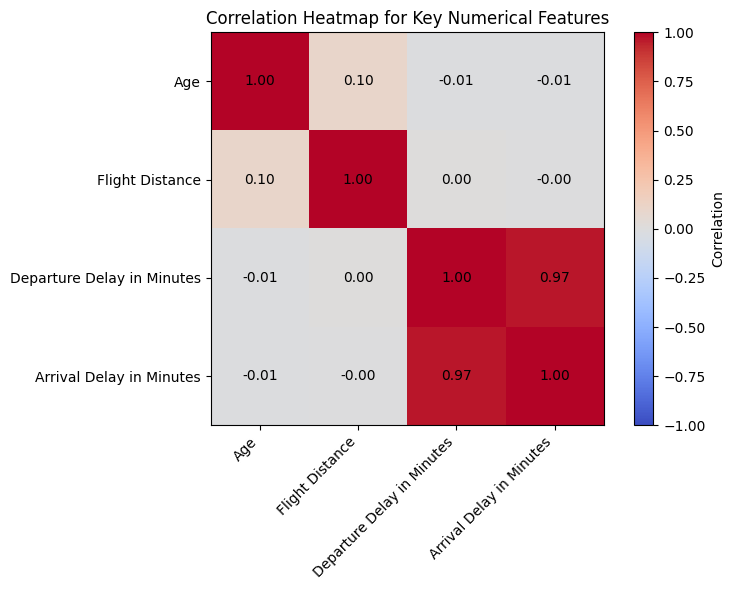

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.099461,-0.010152,-0.012074
Flight Distance,0.099461,1.000000,0.002158,-0.002219
Departure Delay in Minutes,-0.010152,0.002158,1.000000,0.965395
Arrival Delay in Minutes,-0.012074,-0.002219,0.965395,1.000000


In [10]:
# Select the columns we want to study
corr_columns = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

# Create the correlation matrix
correlation_matrix_small = data[corr_columns].corr()

# Make the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix_small, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

# Add labels
plt.xticks(
    np.arange(len(corr_columns)),
    corr_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(corr_columns)),
    corr_columns
)

# Add the actual correlation values inside the boxes
for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix_small.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap for Key Numerical Features")
plt.tight_layout()
plt.show()

# Also print the matrix
correlation_matrix_small

### Checking Whether to Keep the Outliers

I created a correlation heatmap for *Age*, *Flight Distance*, *Departure Delay in Minutes*, and *Arrival Delay in Minutes* to help decide whether the outliers should be removed or kept.

The heatmap also shows that *Flight Distance* does not have a strong correlation with the delay columns. This means long flights are not automatically causing high delays in this dataset. However, large flight distance values can still make sense because some flights are naturally much longer than others.

Based on this check, I decided to keep the outliers instead of removing them. The delay outliers may represent real situations such as weather problems, airport delays, maintenance issues, or other travel disruptions. These extreme values may also be important for predicting passenger satisfaction, so removing them could take away useful information from the model.

## Target Varibles and class imbalance

In [11]:
# Remember that our target variable is "Satisfaction", with two sub categories: 'nuteral or dissatisfied' and 'satisfied'.
# Check target variable distribution

target_counts = data["satisfaction"].value_counts()
target_percentages = data["satisfaction"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary


,Count,Percentage
satisfaction,,
neutral or dissatisfied,58879,56.67
satisfied,45025,43.33


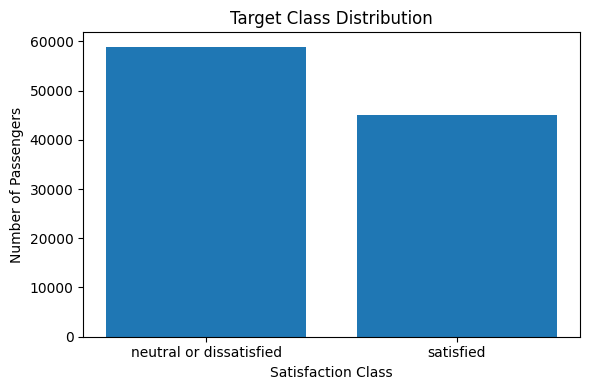

In [12]:
#For visualization, since i am a visual person, I am going to make a bar chart to show the distribution of the target variable "Satisfaction".
plt.figure(figsize=(6, 4))

plt.bar(target_summary.index, target_summary["Count"])

plt.xlabel("Satisfaction Class")
plt.ylabel("Number of Passengers")
plt.title("Target Class Distribution")

plt.tight_layout()
plt.show()

### Target Variable and Class Imbalance
There is a small class imbalance because the *neutral or dissatisfied* class appears more often than the *satisfied* class. However, the imbalance is not extremely large. Because of this, accuracy can still be useful, but I will also look at other evaluation metrics such as precision, recall, F1-score, and a confusion matrix when evaluating the model.

## Data Visualization

For the visualization section, I compare important features between the two target classes: **neutral or dissatisfied** and **satisfied**.

Instead of only looking at raw counts, I use percentages and average differences when helpful. This makes the patterns easier to compare because the two satisfaction classes are not exactly the same size.

The main goals are to understand:

- which numerical features show separation between satisfaction groups,
- which categorical features are connected to satisfaction,
- which service ratings show the biggest differences,
- and whether delay-related variables appear important.

In [18]:
import matplotlib.pyplot as plt

# Make plots look cleaner and consistent
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

class_order = ["neutral or dissatisfied", "satisfied"]

colors = {
    "neutral or dissatisfied": "#6A5ACD",
    "satisfied": "#FF9F45"
}

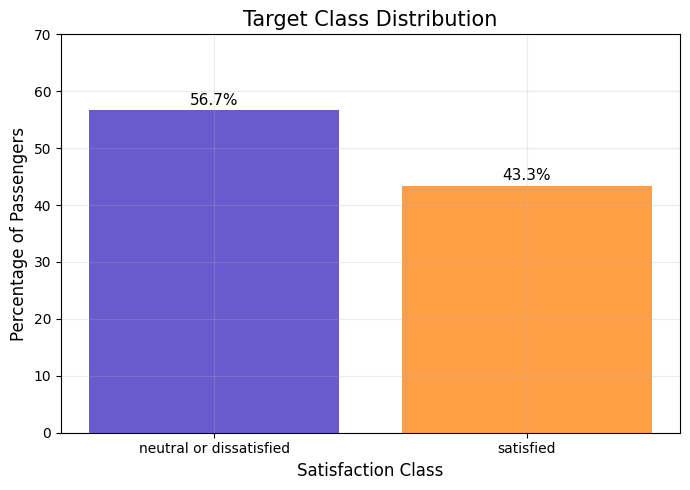

,Count,Percentage
satisfaction,,
neutral or dissatisfied,58879,56.67
satisfied,45025,43.33


In [19]:
target_counts = data["satisfaction"].value_counts()
target_percent = data["satisfaction"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_percent.index,
    target_percent.values,
    color=[colors[label] for label in target_percent.index]
)

plt.title("Target Class Distribution")
plt.xlabel("Satisfaction Class")
plt.ylabel("Percentage of Passengers")

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

target_summary

The target variable has two classes: **neutral or dissatisfied** and **satisfied**.  
There is a small class imbalance, but it is not extreme. Because of this, accuracy can still be useful, but I will also look at other model metrics later.

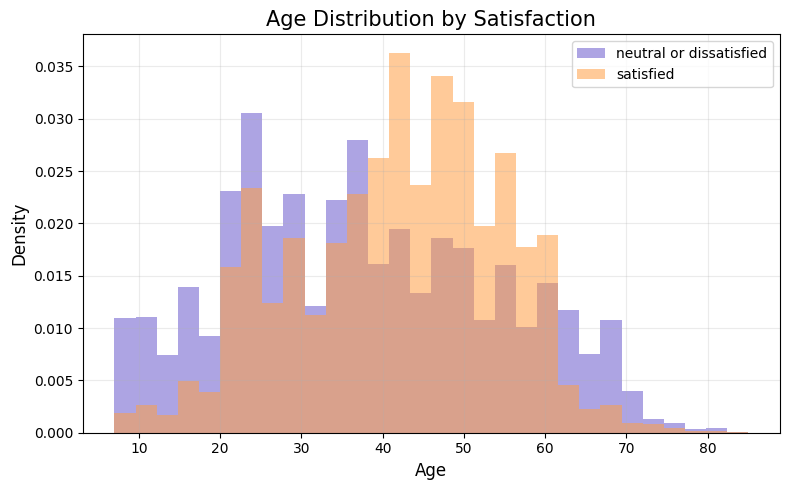

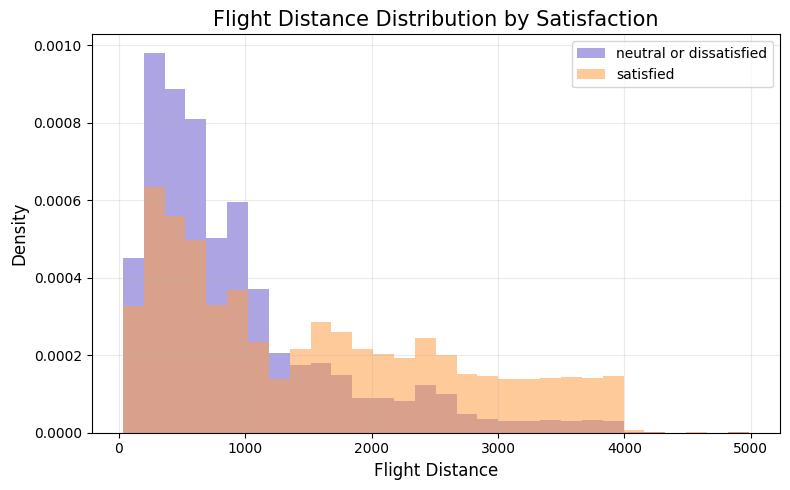

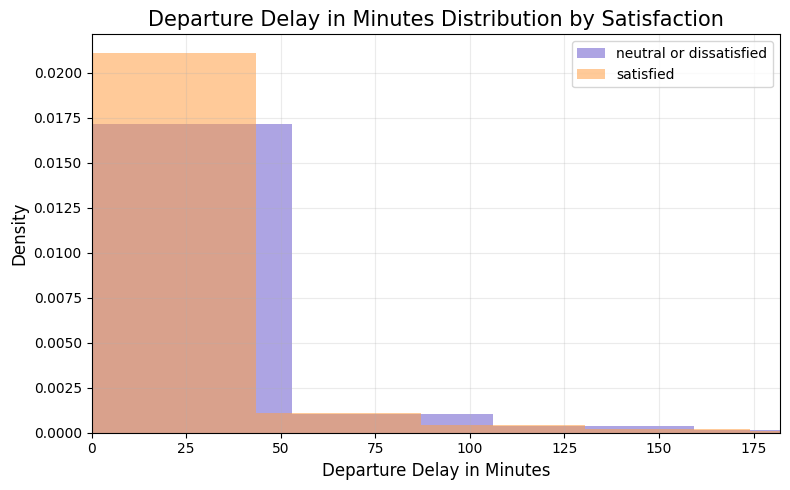

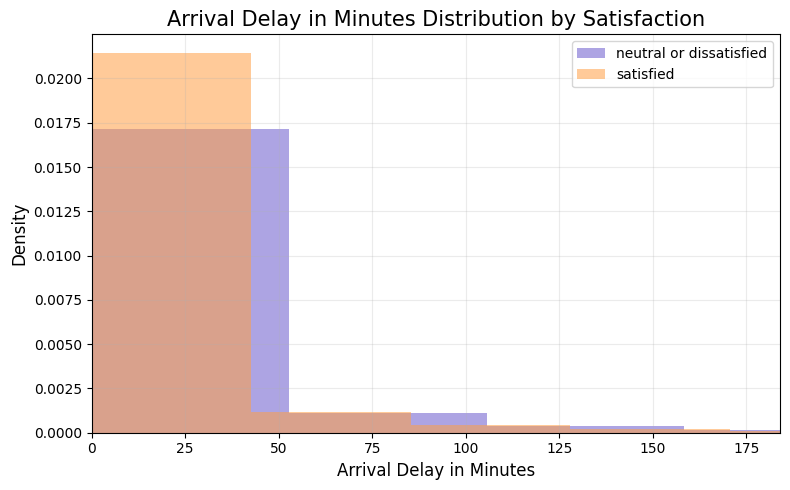

In [20]:
numerical_features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

for col in numerical_features:
    plt.figure(figsize=(8, 5))

    # For delay columns, limit the x-axis to the 99th percentile
    # so the main distribution is easier to see.
    upper_limit = data[col].quantile(0.99)

    for label in class_order:
        subset = data[data["satisfaction"] == label][col]

        plt.hist(
            subset,
            bins=30,
            alpha=0.55,
            density=True,
            label=label,
            color=colors[label]
        )

    plt.title(f"{col} Distribution by Satisfaction")
    plt.xlabel(col)
    plt.ylabel("Density")

    if col in ["Departure Delay in Minutes", "Arrival Delay in Minutes"]:
        plt.xlim(0, upper_limit)

    plt.legend()
    plt.tight_layout()
    plt.show()

The numerical histograms compare the shape of each feature for satisfied and dissatisfied passengers.

The delay variables are highly right-skewed, meaning most flights have small delays, but a smaller number of flights have very large delays. Because of this, the plots use a limited x-axis range to make the main pattern easier to see.

Age and flight distance show some differences between the two groups, but the distributions still overlap. This means these features may help the model, but they probably cannot predict satisfaction perfectly by themselves.

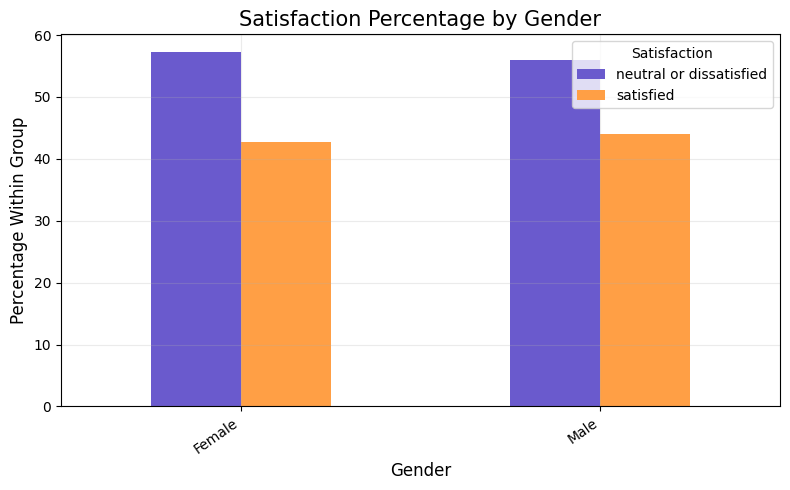

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,57.26,42.74
Male,56.05,43.95


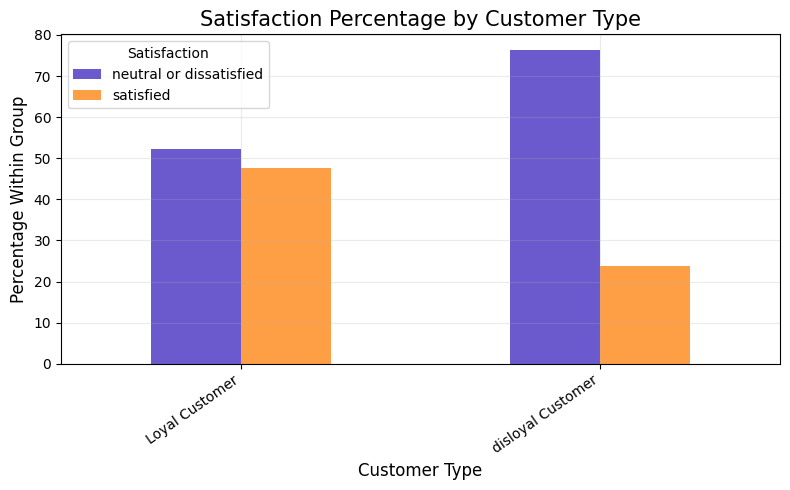

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.27,47.73
disloyal Customer,76.33,23.67


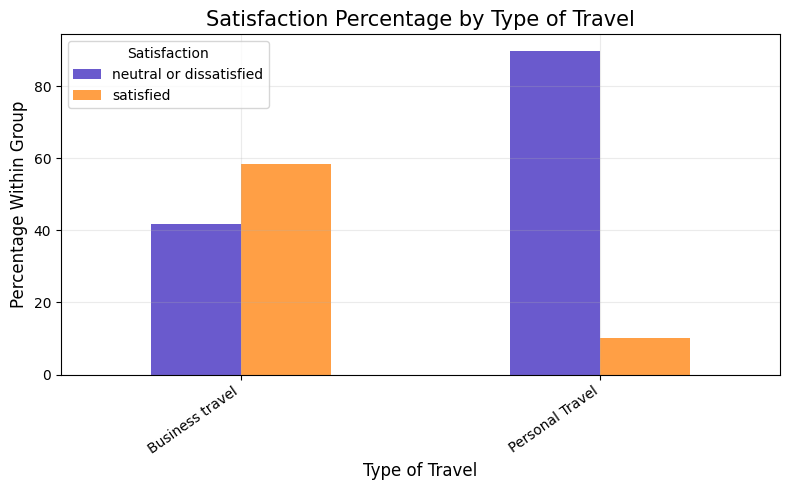

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.74,58.26
Personal Travel,89.83,10.17


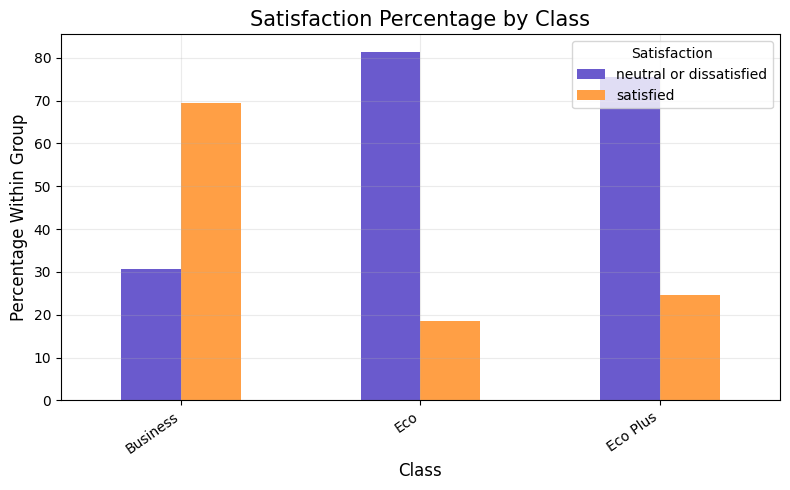

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.57,69.43
Eco,81.39,18.61
Eco Plus,75.39,24.61


In [21]:
categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

for col in categorical_features:
    # Convert counts into percentages within each category
    prop_table = pd.crosstab(data[col], data["satisfaction"], normalize="index") * 100

    prop_table = prop_table[class_order]

    ax = prop_table.plot(
        kind="bar",
        figsize=(8, 5),
        color=[colors["neutral or dissatisfied"], colors["satisfied"]]
    )

    plt.title(f"Satisfaction Percentage by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage Within Group")
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="Satisfaction")
    plt.tight_layout()
    plt.show()

    display(prop_table.round(2))

### Categorical Feature Summary

The categorical plots show that **Gender** does not appear to strongly separate the satisfaction groups because male and female passengers have very similar satisfaction patterns.

However, **Customer Type**, **Type of Travel**, and **Class** show stronger differences. Disloyal customers have a much higher percentage of neutral or dissatisfied responses compared with loyal customers. Personal travel passengers are also much more likely to be neutral or dissatisfied, while business travel passengers show a higher satisfaction percentage. 

The strongest categorical pattern appears in **Class**. Business class passengers have a much higher satisfaction percentage, while Eco and Eco Plus passengers are more likely to be neutral or dissatisfied. This suggests that travel class and travel purpose may be important predictors for the machine learning model.

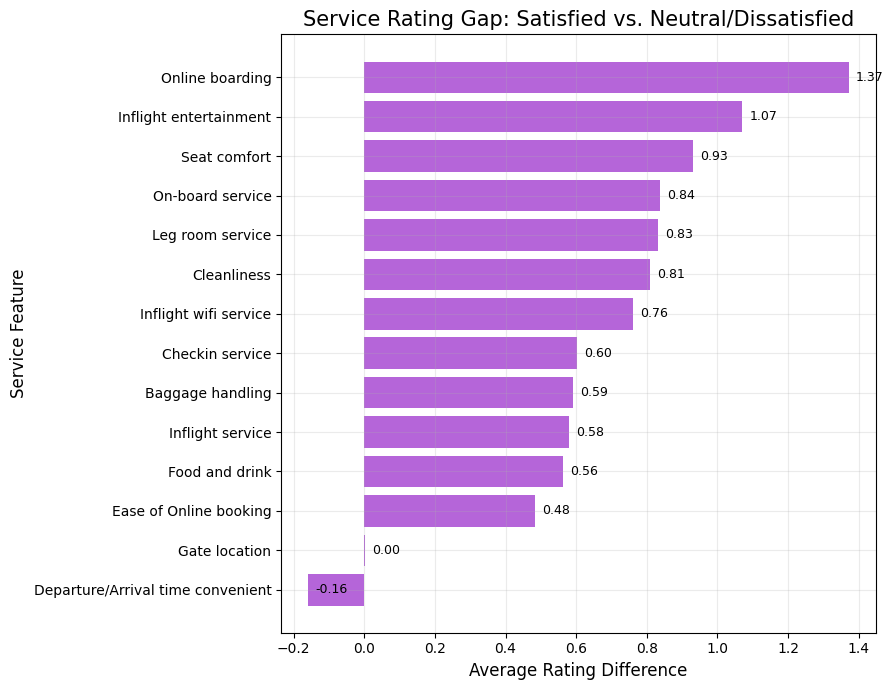

satisfaction,neutral or dissatisfied,satisfied,Difference
Departure/Arrival time convenient,3.13,2.97,-0.16
Gate location,2.98,2.98,0.00
Ease of Online booking,2.55,3.03,0.48
Food and drink,2.96,3.52,0.56
Inflight service,3.39,3.97,0.58
Baggage handling,3.38,3.97,0.59
Checkin service,3.04,3.65,0.60
Inflight wifi service,2.40,3.16,0.76
Cleanliness,2.94,3.74,0.81
Leg room service,2.99,3.82,0.83


In [22]:
service_columns = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

service_means = data.groupby("satisfaction")[service_columns].mean().T

service_means["Difference"] = (
    service_means["satisfied"] - service_means["neutral or dissatisfied"]
)

service_means_sorted = service_means.sort_values("Difference", ascending=True)

plt.figure(figsize=(9, 7))

plt.barh(
    service_means_sorted.index,
    service_means_sorted["Difference"],
    color="#B565D9"
)

plt.title("Service Rating Gap: Satisfied vs. Neutral/Dissatisfied")
plt.xlabel("Average Rating Difference")
plt.ylabel("Service Feature")

# Add value labels
for index, value in enumerate(service_means_sorted["Difference"]):
    plt.text(value + 0.02, index, f"{value:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

service_means_sorted.round(2)

### Service Rating Gap Summary

The service rating gap chart shows the average difference between satisfied and neutral/dissatisfied passengers for each service feature.

The largest gap appears in **Online boarding**, which suggests that online boarding may be one of the strongest service-related predictors of satisfaction. Other features with large gaps include **Inflight entertainment**, **Seat comfort**, **On-board service**, **Leg room service**, and **Cleanliness**.

Features such as **Gate location** and **Departure/Arrival time convenient** have very small or negative gaps, which suggests they may be less useful for predicting satisfaction compared with the main service-quality features.

Overall, this chart supports the main goal of the project because it identifies which controllable airline service factors seem most connected to passenger satisfaction.

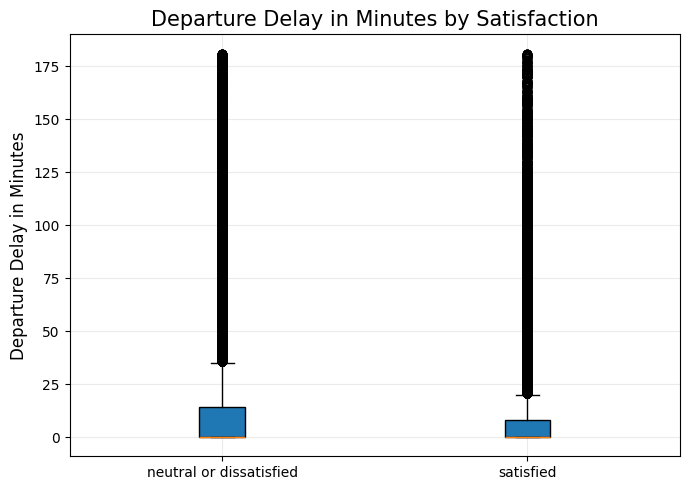

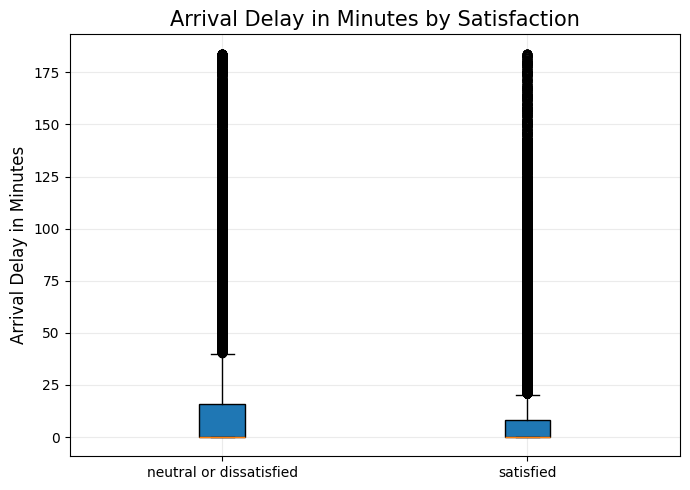

In [23]:
delay_columns = [
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

for col in delay_columns:
    plt.figure(figsize=(7, 5))

    # Limit plot to 99th percentile for readability
    upper_limit = data[col].quantile(0.99)
    temp = data[data[col] <= upper_limit]

    groups = [
        temp[temp["satisfaction"] == "neutral or dissatisfied"][col],
        temp[temp["satisfaction"] == "satisfied"][col]
    ]

    plt.boxplot(
        groups,
        tick_labels=["neutral or dissatisfied", "satisfied"],
        patch_artist=True
    )

    plt.title(f"{col} by Satisfaction")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Delay Feature Summary

The delay boxplots show that both departure delay and arrival delay are highly skewed. Most flights have small delays, while a smaller number of flights have much larger delays.

The dissatisfied group appears to have slightly larger delay values, but the difference is not as visually strong as the service-rating features. This suggests that delay may still help the model, but service ratings may be more important for predicting satisfaction.

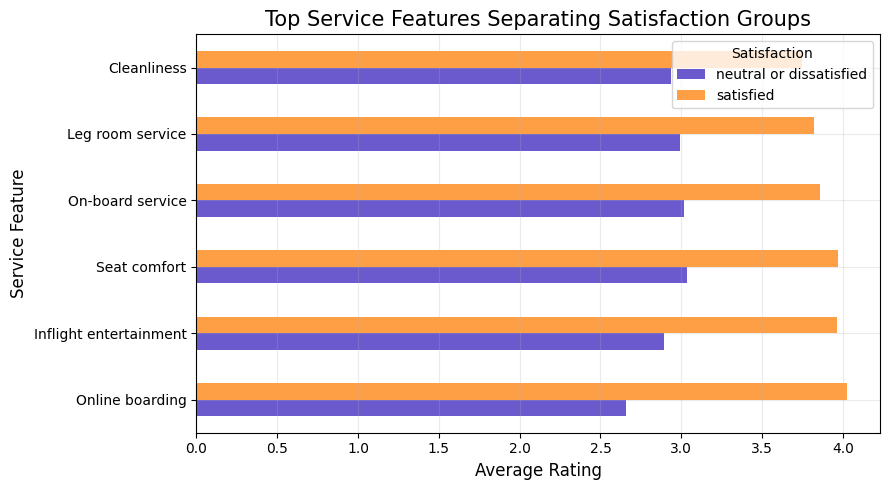

satisfaction,neutral or dissatisfied,satisfied
Online boarding,2.66,4.03
Inflight entertainment,2.89,3.96
Seat comfort,3.04,3.97
On-board service,3.02,3.86
Leg room service,2.99,3.82
Cleanliness,2.94,3.74


In [24]:
top_service_features = service_means_sorted["Difference"].sort_values(ascending=False).head(6).index

top_means = data.groupby("satisfaction")[top_service_features].mean().T

ax = top_means.plot(
    kind="barh",
    figsize=(9, 5),
    color=[colors["neutral or dissatisfied"], colors["satisfied"]]
)

plt.title("Top Service Features Separating Satisfaction Groups")
plt.xlabel("Average Rating")
plt.ylabel("Service Feature")
plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()

top_means.round(2)

This chart focuses only on the service features with the largest average difference between satisfied and dissatisfied passengers.

These features are important because they may be the most useful service-related predictors in the machine learning model. They also give practical business insight because airlines may be able to improve these areas directly.

## Best Feature from Visualization

Based on the visualizations, **Online boarding** appears to be one of the strongest individual features for predicting passenger satisfaction.

This feature has the largest average rating gap between satisfied and neutral/dissatisfied passengers. Satisfied passengers gave much higher online boarding ratings on average, while neutral or dissatisfied passengers gave lower ratings.

This suggests that online boarding may have strong predictive value because it separates the two satisfaction groups better than many other features. However, it is still not enough to predict satisfaction perfectly by itself, so the machine learning model should combine online boarding with other important features such as inflight entertainment, seat comfort, class, type of travel, and customer type.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [27]:
# We first need to make a new copy of cleaned dataset for macine learning :) 
machine_learning_data = data.copy()

#Checking the columns before preparing the data
machine_learning_data.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [28]:
# Encode the target variable.
# neutral or dissatisfied = 0
# satisfied = 1

machine_learning_data["satisfaction_encoded"] = machine_learning_data["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

# Check that the encoding worked
machine_learning_data[["satisfaction", "satisfaction_encoded"]].head()

,satisfaction,satisfaction_encoded
0,neutral or dissatisfied,0
1,neutral or dissatisfied,0
2,satisfied,1
3,neutral or dissatisfied,0
4,satisfied,1


In [29]:
# Separate the target variable.
# This is what the model will try to predict.

y = machine_learning_data["satisfaction_encoded"]


# Create the feature dataset.
# We remove:
# - satisfaction because it is the original text target
# - satisfaction_encoded because it is the target we are predicting
# - id because it is only an identification number, not a real feature

X = machine_learning_data.drop(columns=["satisfaction", "satisfaction_encoded", "id"])


# Check which categorical columns are still inside X.

categorical_columns = X.select_dtypes(include=["object"]).columns

categorical_columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')

In [30]:
# One-hot encode the categorical feature columns.
# This changes text categories into numeric 0/1 columns.

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)


# Check the new encoded dataset.

X_encoded.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,13,460,3,4,3,1,5,3,5,5,...,4,5,5,25,18.0,1,0,1,0,1
1,25,235,3,2,3,3,1,3,1,1,...,1,4,1,1,6.0,1,1,0,0,0
2,26,1142,2,2,2,2,5,5,5,5,...,4,4,5,0,0.0,0,0,0,0,0
3,25,562,2,5,5,5,2,2,2,2,...,1,4,2,11,9.0,0,0,0,0,0
4,61,214,3,3,3,3,4,5,5,3,...,3,3,3,0,0.0,1,0,0,0,0


In [31]:
print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

Original feature shape: (103904, 22)
Encoded feature shape: (103904, 23)


In [32]:
# Check all columns after one-hot encoding
X_encoded.columns

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Gender_Male', 'Customer Type_disloyal Customer',
       'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus'],
      dtype='object')

In [33]:
# Create a summary table for the encoded machine learning features.
# This is similar to the table we made at the beginning,
# but now it checks X_encoded after one-hot encoding.

encoded_summary_rows = []

for column in X_encoded.columns:
    
    # Check if the column is numerical or categorical-like.
    # After one-hot encoding, all columns should be numeric.
    if X_encoded[column].nunique() == 2:
        column_type = "Encoded / Binary"
        values_or_range = str(X_encoded[column].min()) + " to " + str(X_encoded[column].max())
    else:
        column_type = "Numerical"
        values_or_range = str(X_encoded[column].min()) + " to " + str(X_encoded[column].max())
    
    # Count missing values
    missing_count = X_encoded[column].isnull().sum()
    
    # Count unique values
    unique_count = X_encoded[column].nunique()
    
    encoded_summary_rows.append({
        "Column Name": column,
        "Type": column_type,
        "Values or Range": values_or_range,
        "Missing Values": missing_count,
        "Number of Unique Values": unique_count
    })

encoded_summary_table = pd.DataFrame(encoded_summary_rows)

encoded_summary_table

,Column Name,Type,Values or Range,Missing Values,Number of Unique Values
0,Age,Numerical,7 to 85,0,75
1,Flight Distance,Numerical,31 to 4983,0,3802
2,Inflight wifi service,Numerical,0 to 5,0,6
3,Departure/Arrival time convenient,Numerical,0 to 5,0,6
4,Ease of Online booking,Numerical,0 to 5,0,6
5,Gate location,Numerical,0 to 5,0,6
6,Food and drink,Numerical,0 to 5,0,6
7,Online boarding,Numerical,0 to 5,0,6
8,Seat comfort,Numerical,0 to 5,0,6
9,Inflight entertainment,Numerical,0 to 5,0,6


### Encoded Feature Summary

After one-hot encoding, I created another summary table to check the machine learning feature dataset. This table shows each encoded feature, its type, value range, missing values, and number of unique values.

The categorical features were converted into binary 0/1 columns. This means the dataset no longer has text-based feature columns, which makes it ready for machine learning models.

The table also confirms that there are no missing values remaining in the encoded feature dataset.

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [34]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets.
# X_encoded contains the features.
# y contains the target variable.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (83123, 23)
X_test shape: (20781, 23)
y_train shape: (83123,)
y_test shape: (20781,)


### Train/Test Split

I split the dataset into training and testing sets. I used an 80/20 split, meaning 80% of the data is used for training and 20% is used for testing. I used *stratify = y* so that the training and testing sets keep the same class balance as the original dataset. Since the target variable has about 56.67% neutral or dissatisfied passengers and 43.33% satisfied passengers, stratifying helps make sure both sets have similar proportions.

In [35]:
from sklearn.preprocessing import StandardScaler

# Create the scaler.
scaler = StandardScaler()

# Fit the scaler only on the training data.
# This prevents data leakage from the test set.
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data.
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


### Feature Scaling

Feature scaling is important because the numerical features have very different ranges. For example, service ratings are usually between 0 and 5, while flight distance can go up to almost 5,000 and delay values can go over 1,000 minutes.

I used StandardScaler to rescale the features. StandardScaler changes the data so each feature has a mean close to 0 and a standard deviation close to 1.

I fitted the scaler only on the training data and then applied it to the test data. This prevents data leakage.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the logistic regression model.
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using the scaled training data.
logistic_model.fit(X_train_scaled, y_train)

# Make predictions on the test data.
y_pred = logistic_model.predict(X_test_scaled)

# Evaluate the model.
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8766180645782204

Confusion Matrix:
[[10637  1139]
 [ 1425  7580]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     11776
           1       0.87      0.84      0.86      9005

    accuracy                           0.88     20781
   macro avg       0.88      0.87      0.87     20781
weighted avg       0.88      0.88      0.88     20781



### Logistic Regression Results

The first machine learning model I used was Logistic Regression. This model was used as a baseline because the target variable has two classes: *neutral or dissatisfied* and *satisfied*.

The Logistic Regression model had an accuracy of about **87.66%**. This means the model correctly predicted the passenger satisfaction class for about 87.66% of the test data.

The confusion matrix was:

| Actual Class | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0: neutral or dissatisfied | 10,637 | 1,139 |
| Actual 1: satisfied | 1,425 | 7,580 |

In this project:

- **0 = neutral or dissatisfied**
- **1 = satisfied**

The confusion matrix shows where the model was correct and where it made mistakes. The model correctly predicted **10,637** neutral or dissatisfied passengers and **7,580** satisfied passengers. This means the model made **18,217 correct predictions**.

The model incorrectly predicted **1,139** neutral or dissatisfied passengers as satisfied. It also incorrectly predicted **1,425** satisfied passengers as neutral or dissatisfied. This means the model made **2,564 incorrect predictions**.

The classification report shows that the model performed well for both classes. For class 0, the recall was **0.90**, meaning the model correctly found 90% of the neutral or dissatisfied passengers. For class 1, the recall was **0.84**, meaning the model correctly found 84% of the satisfied passengers.

Overall, Logistic Regression performed well as a baseline model. The model was slightly better at identifying neutral or dissatisfied passengers than satisfied passengers, but the precision, recall, and F1-scores were strong for both classes.

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Decision Tree model.
# random_state keeps the result consistent every time the notebook runs.
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model.
# Decision Trees do not require scaled data, so I use X_train instead of X_train_scaled.
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test data.
decision_tree_predictions = decision_tree_model.predict(X_test)

# Calculate accuracy.
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)

print("Decision Tree Accuracy:", decision_tree_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, decision_tree_predictions))

print("\nClassification Report:")
print(classification_report(y_test, decision_tree_predictions))

Decision Tree Accuracy: 0.9447572301621674

Confusion Matrix:
[[11146   630]
 [  518  8487]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     11776
           1       0.93      0.94      0.94      9005

    accuracy                           0.94     20781
   macro avg       0.94      0.94      0.94     20781
weighted avg       0.94      0.94      0.94     20781



### Decision Tree Results

The second machine learning model I used was a Decision Tree Classifier. Unlike Logistic Regression, a Decision Tree does not require scaled data, so I used the original training and testing feature sets.

The Decision Tree model had an accuracy of about **94.48%**, which is higher than the Logistic Regression accuracy of about **87.66%**.

The confusion matrix was:

| Actual Class | Predicted 0 | Predicted 1 |
|---|---:|---:|
| Actual 0: neutral or dissatisfied | 11,146 | 630 |
| Actual 1: satisfied | 518 | 8,487 |

In this project:

- **0 = neutral or dissatisfied**
- **1 = satisfied**

The model correctly predicted **11,146** neutral or dissatisfied passengers and **8,487** satisfied passengers. This means the model made **19,633 correct predictions**.

The model incorrectly predicted **630** neutral or dissatisfied passengers as satisfied. It also incorrectly predicted **518** satisfied passengers as neutral or dissatisfied. This means the model made **1,148 incorrect predictions**.

The classification report also shows strong results. For class 0, the recall was **0.95**, meaning the model correctly found 95% of the neutral or dissatisfied passengers. For class 1, the recall was **0.94**, meaning the model correctly found 94% of the satisfied passengers.

Overall, the Decision Tree performed better than Logistic Regression. This suggests that the relationship between passenger features and satisfaction may not be fully linear, and a tree-based model can capture more complex patterns in the data.

In [38]:
# Compare model accuracy scores

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, decision_tree_accuracy]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.876618
1,Decision Tree,0.944757


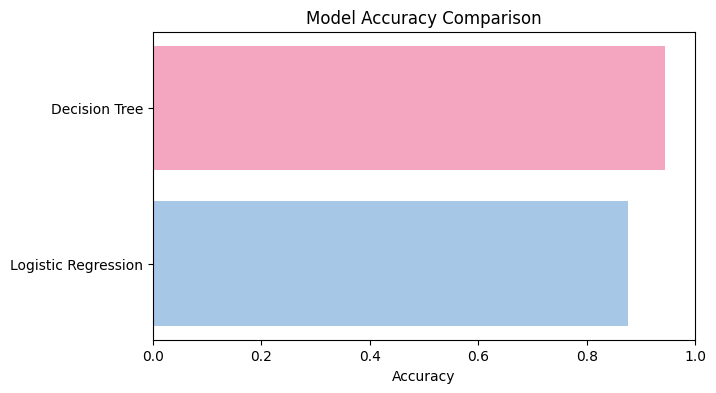

In [39]:
# Visualize the model comparison.

plt.figure(figsize=(7, 4))

plt.barh(
    model_comparison["Model"],
    model_comparison["Accuracy"],
    color=["#A7C7E7", "#F4A6C1"]
)

plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)

plt.show()

### Model Comparison

I compared Logistic Regression and Decision Tree models. Logistic Regression had an accuracy of about **87.66%**, while the Decision Tree had an accuracy of about **94.48%**.

The Decision Tree performed better on this dataset. This may be because passenger satisfaction depends on many feature combinations, such as service ratings, type of travel, class, and delays. A Decision Tree can capture these types of decision patterns better than a simple linear model.

## Feature Importance from the Decision Tree

In [40]:
# Get feature importance values from the Decision Tree model.
# Higher values mean the feature was more important for making predictions.

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": decision_tree_model.feature_importances_
})

# Sort features from most important to least important.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show the top 10 most important features.
feature_importance.head(10)

,Feature,Importance
7,Online boarding,0.363000
2,Inflight wifi service,0.179607
20,Type of Travel_Personal Travel,0.146925
9,Inflight entertainment,0.042091
19,Customer Type_disloyal Customer,0.031732
13,Checkin service,0.030323
1,Flight Distance,0.025520
0,Age,0.021778
14,Inflight service,0.019786
11,Leg room service,0.018676


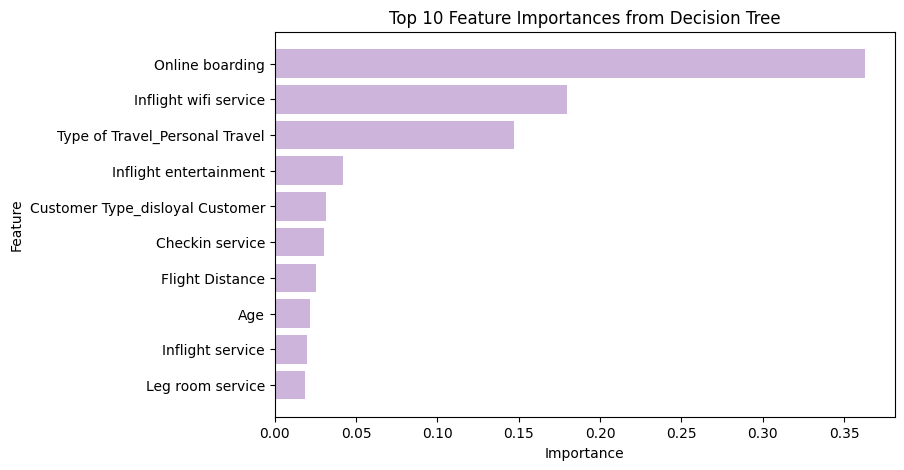

In [41]:
# Plot the top 10 most important features.

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#CDB4DB"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances from Decision Tree")

# Put the most important feature at the top.
plt.gca().invert_yaxis()

plt.show()

### Feature Importance

I used the Decision Tree model to check which features were most important for predicting passenger satisfaction. Feature importance shows how much each feature helped the model make decisions.

The most important features appear at the top of the chart. These features are likely the strongest predictors of whether a passenger is satisfied or neutral/dissatisfied.

This step is useful because it helps connect the machine learning results back to the earlier data visualization section. Features that looked different between the two classes in the graphs should also appear as important features in the model.